# Logistic Regression From Scratch

In [66]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

### Sigmoid Function

$$\hat{y}^{(i)}
=
g_{w,b}(x^{(i)})
=
\sigma(z^{(i)})
=
\frac{1}{1+e^{-z^{(i)}}}$$

In [67]:
def sigmoid(logit):
    '''
    Params:
        logit - raw class scores/logits

    Returns:
        class probabilities for prediction
    '''
    
    return 1 / (1 + np.exp(-logit))

### Log Reg Cost Function (Binary Cross Entropy)
$$J(w,b)
=
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y^{(i)}\log\left(g_{w,b}\left(\mathbf{x}^{(i)}\right)\right)
+
\left(1-y^{(i)}\right)
\log\left(1-g_{w,b}\left(\mathbf{x}^{(i)}\right)\right)
\right]$$

In [68]:
def blr_compute_cost(X, Y, w, b):
    '''
    Params:
        X - sample data
        Y - sample target values
        w - model weights
        b - model bias
    
    Returns:
        cost - binary cross entropy cost
    '''

    m = X.shape[0]

    y_hat = sigmoid(X @ w + b)

    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    cost = np.sum((-1 / m) * (Y * np.log(y_hat) + (1 - Y) * np.log(1 - y_hat)))

    return cost

### Gradient Equations

a. with respect to each w: 
$$ \frac{\partial J}{\partial w_j}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}^{(i)} - y^{(i)}\right)x_j^{(i)} $$

b. with respect to b:
$$ \frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}^{(i)} - y^{(i)}\right) $$

In [69]:
def blr_compute_gradient(X, Y, w, b):
    '''
    Params:
        X - sample data
        Y - sample target values
        w - model weights
        b - model bias

    Returns:
        dj_dw - cost gradient wrt weights
        dj_db - cost gradient wrt bias
    '''
    
    m = X.shape[0]

    g_x = sigmoid(X @ w + b)

    y_diff = g_x - Y

    dj_dw = (1 / m) * (X.T @ y_diff)
    dj_db = (1 / m) * np.sum(y_diff)

    return dj_dw, dj_db

### Gradient Descent Function for Binary Logistic Regression

In [70]:
def blr_gradient_descent(X, Y, w_init, b_init, lr=0.01, num_iter=1000, reg_lambda=0):
    '''
    Params:
        X - sample data
        Y - sample target values
        w_init - initial weights
        b_init - inital bias
        lr - learning rate hyperparameter
        num_iter - number of iterations
        reg_lambda - regularization hyperparameter

    Returns:
        w - updated weights
        b - updates bias
        cost_history - cost at each iteration
    '''
    
    cost_history = []

    m = X.shape[0]
    w = w_init.copy()
    b = b_init

    for i in range(num_iter):
        dj_dw, dj_db = blr_compute_gradient(X, Y, w, b)

        if reg_lambda != 0:
            dj_dw = dj_dw + (reg_lambda / m) * w

        w = w - lr * dj_dw
        b = b - lr * dj_db

        cost = blr_compute_cost(X, Y, w, b)

        if reg_lambda != 0:
            cost = cost + (reg_lambda / (2 * m)) * np.sum(w ** 2)

        cost_history.append(cost)

    return w, b, cost_history

### Testing

Accuracy (Evaluation of training):
0.9159273909848497

First 5 costs:
[np.float64(0.6911724877702755), np.float64(0.6892096332672797), np.float64(0.6872585305721364), np.float64(0.6853190938280892), np.float64(0.6833912377990525)]

Last 5 costs:
[np.float64(0.27202736398247584), np.float64(0.2719657882280284), np.float64(0.2719043431057896), np.float64(0.27184302824620066), np.float64(0.2717818432810003)]


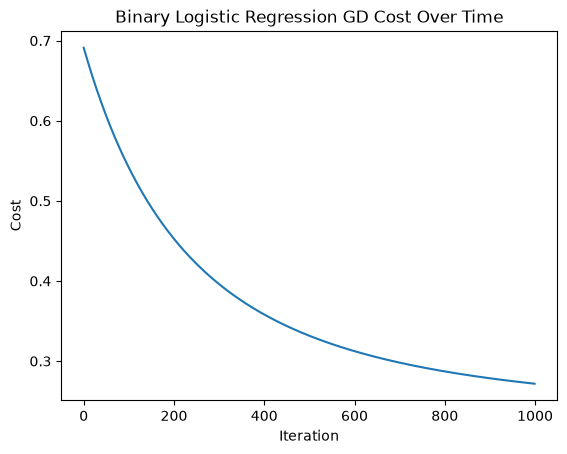

In [71]:
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "kamilpytlak/personal-key-indicators-of-heart-disease",
  "2020/heart_2020_cleaned.csv",
)

Y = (df[["HeartDisease"]].values == "Yes").astype(int)

X_raw_df = df.drop(columns=["HeartDisease"])

X_raw_df = pd.get_dummies(X_raw_df, drop_first=True)

X_raw_df = X_raw_df.astype(float)

X_raw = X_raw_df.values

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_std[X_std == 0] = 1

X_scaled = (X_raw - X_mean) / X_std

w_init = np.zeros((X_scaled.shape[1], 1))
b_init = 0

w, b, cost_history = blr_gradient_descent(X_scaled, Y, w_init, b_init, num_iter=1000, lr=0.01, reg_lambda=0)

Y_prob = sigmoid(X_scaled @ w + b)
Y_pred = (Y_prob >= 0.5).astype(int)

accuracy = np.mean(Y_pred == Y)

print("Accuracy (Evaluation of training):")
print(accuracy)

print("\nFirst 5 costs:")
print(cost_history[:5])

print("\nLast 5 costs:")
print(cost_history[-5:])

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Binary Logistic Regression GD Cost Over Time")
plt.show()

### Softmax Function

$$ \hat{y}_k^{(i)}
=
\frac{e^{z_k^{(i)}}}
{\sum_{\ell=1}^{K} e^{z_\ell^{(i)}}} $$

In [72]:
def softmax(logit):
    '''
    Params:
        logit - raw class scores/logits

    Returns:
        class probabilities for prediction
    '''

    # shifted logits used to prevent np overflow for large logits
    shifted_logits = logit - np.max(logit, axis=1, keepdims=True)
    return np.exp(shifted_logits) / np.sum(np.exp(shifted_logits), axis=1, keepdims=True)

### Multinomial Log Reg Cost Function (Negative Log Likelihood/Categorical Cross Entropy):

$$ J(W,b)
=
-\frac{1}{m}
\sum_{i=1}^{m}
\sum_{k=1}^{K}
y_k^{(i)}
\log\left(\hat{y}_k^{(i)}\right) $$

In [73]:
def mlr_compute_cost(X, Y, w, b):
    """
    Params:
        X - sample data
        Y - one-hot sample target values
        w - model weights
        b - model bias

    Returns:
        cost - categorical cross entropy cost
    """

    m = X.shape[0]

    logits = X @ w + b
    y_hat = softmax(logits)

    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    cost = (-1 / m) * np.sum(Y * np.log(y_hat))

    return cost

### Gradient Equations

a. with respect to each w: 
$$ \frac{\partial J}{\partial w_k}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}_k^{(i)} - y_k^{(i)}\right)x^{(i)}$$

b. with respect to b:
$$ \frac{\partial J}{\partial b_k}
=
\frac{1}{m}
\sum_{i=1}^{m}
\left(\hat{y}_k^{(i)} - y_k^{(i)}\right)$$

In [74]:
def mlr_compute_gradient(X, Y, w, b):
    """
    Params:
        X - sample data
        Y - one-hot sample target values
        w - model weights
        b - model bias

    Returns:
        dj_dw - gradient wrt weights
        dj_db - gradient wrt biases
    """

    m = X.shape[0]

    logits = X @ w + b
    y_hat = softmax(logits)

    y_diff = y_hat - Y

    dj_dw = (1 / m) * (X.T @ y_diff)
    dj_db = (1 / m) * np.sum(y_diff, axis=0, keepdims=True)

    return dj_dw, dj_db

### Gradient Descent Function for Multinomial Logistic Regression

In [75]:
def mlr_gradient_descent(X, Y, w_init, b_init, lr=0.01, num_iter=1000, reg_lambda=0):
    """
    Params:
        X - sample data
        Y - one-hot sample target values
        w_init - initial weights
        b_init - inital bias
        lr - learning rate hyperparameter
        num_iter - number of iterations
        reg_lambda - regularization hyperparameter

    Returns:
        w - updated weights
        b - updated biases
        cost_history - cost at each iteration
    """

    m = X.shape[0]

    w = w_init.copy()
    b = b_init.copy()

    cost_history = []

    for i in range(num_iter):
        dj_dw, dj_db = mlr_compute_gradient(X, Y, w, b)
        
        if reg_lambda != 0:
            dj_dw = dj_dw + (reg_lambda / m) * w

        w = w - (lr * dj_dw)
        b = b - (lr * dj_db)

        cost = mlr_compute_cost(X, Y, w, b)

        if reg_lambda != 0:
            cost = cost + (reg_lambda / (2 * m)) * np.sum(w ** 2)

        cost_history.append(cost)

    return w, b, cost_history

### Testing

Final w:
[[-1.26260759  0.70980175  0.55280584]
 [ 1.31358042 -0.49824173 -0.81533869]
 [-2.07568713 -0.1223574   2.19804453]
 [-1.94065168 -0.91619696  2.85684864]]

Final b:
[[-0.52263804  2.10349531 -1.58085727]]

Classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Accuracy (Evaluation of training):
0.9733333333333334

First 5 costs:
[np.float64(1.0070832276502428), np.float64(0.9318734375154027), np.float64(0.8699106905005088), np.float64(0.8185531244974894), np.float64(0.7756317133334992)]

Last 5 costs:
[np.float64(0.1241874275647767), np.float64(0.1241273044257867), np.float64(0.12406727802167669), np.float64(0.12400734811275049), np.float64(0.12394751446010346)]


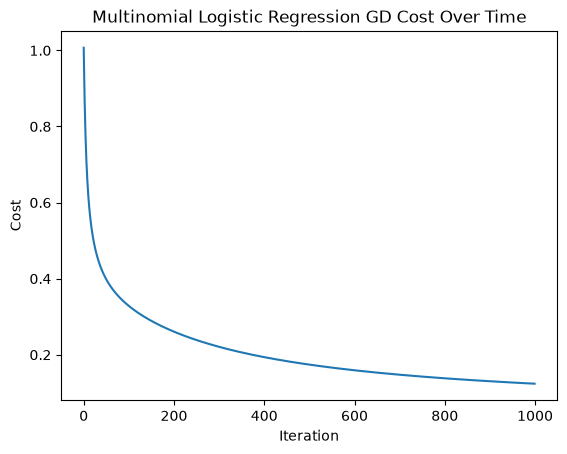

In [76]:
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/iris",
  "Iris.csv",
)

if "Id" in df.columns:
    df = df.drop(columns=["Id"])

X_raw = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]].values

class_names = np.unique(df["Species"].values)
class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}

Y_labels = df["Species"].map(class_to_idx).values

K = len(class_names)
Y = np.eye(K)[Y_labels]

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_std[X_std == 0] = 1

X_scaled = (X_raw - X_mean) / X_std

w_init = np.zeros((X_scaled.shape[1], K))
b_init = np.zeros((1, K))

w, b, cost_history = mlr_gradient_descent(X_scaled, Y, w_init, b_init, num_iter=1000, lr=0.1, reg_lambda=0)

Y_prob = softmax(X_scaled @ w + b)
Y_pred = np.argmax(Y_prob, axis=1)
Y_true = np.argmax(Y, axis=1)

accuracy = np.mean(Y_pred == Y_true)

print("Final w:")
print(w)

print("\nFinal b:")
print(b)

print("\nClasses:")
print(class_names)

print("\nAccuracy (Evaluation of training):")
print(accuracy)

print("\nFirst 5 costs:")
print(cost_history[:5])

print("\nLast 5 costs:")
print(cost_history[-5:])

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Multinomial Logistic Regression GD Cost Over Time")
plt.show()